# BERT Adaptation and Representation Analysis


Compare full fine-tuning, LoRA, and a frozen-encoder classification head using limited labeled data. The task predicts book-title classes from preprocessed descriptions. Layer-wise analysis compares pretrained and adapted representations.

Generate `../lexical-book-search/preprocessed.json` before running this notebook.


In [ ]:
# Run once in a fresh environment. The notebook itself does not require torchao.
%pip -q install -U "transformers>=4.40" "peft>=0.10" "accelerate>=0.28"


In [ ]:
import json
import os
import random
from abc import ABC, abstractmethod
from collections import Counter
from pathlib import Path

import numpy as np
import random
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, Subset
from tqdm.auto import tqdm
from transformers import BertModel, BertTokenizer
from peft import LoraConfig, get_peft_model

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


In [ ]:
# =========================================
# Load book-search preprocessed JSON data
# =========================================
# Use the book-search preprocessed records.
# In that file, title and description fields are already tokenized/preprocessed
# lists. BERT expects strings, so we reconstruct each field by joining its tokens
# with spaces. This preserves the book-search preprocessing while making the data
# compatible with BertTokenizer.

def _join_preprocessed_tokens(value):
    """Convert a token list (or a scalar) from preprocessed.json into text."""
    if value is None:
        return ""

    if isinstance(value, (list, tuple)):
        return " ".join(
            str(token).strip()
            for token in value
            if str(token).strip()
        ).strip()

    return str(value).strip()


def _records_from_book_json(payload):
    """Read title/description examples from the book-search JSON structure."""
    if isinstance(payload, dict):
        for key in ("data", "books", "records", "items"):
            if isinstance(payload.get(key), list):
                payload = payload[key]
                break
        else:
            payload = list(payload.values())

    records = []
    for item in payload:
        if not isinstance(item, dict):
            continue

        title = _join_preprocessed_tokens(item.get("title", []))
        description = _join_preprocessed_tokens(item.get("description", []))

        if title and description:
            records.append(
                {
                    "title": title,
                    "description": description,
                }
            )

    return records


json_candidates = [
    Path("../lexical-book-search/preprocessed.json"),
    Path("lexical-book-search/preprocessed.json"),
]

DATA_SOURCE = None
data = None

for candidate in json_candidates:
    if not candidate.exists():
        continue

    with candidate.open("r", encoding="utf-8") as file:
        data = _records_from_book_json(json.load(file))

    if data:
        DATA_SOURCE = str(candidate)
        break

if not data:
    raise FileNotFoundError(
        "book-search preprocessed.json was not found. "
        "Place it in the same directory as this notebook, or update "
        "`json_candidates` with its location."
    )

print(f"Loaded {len(data):,} usable records from book-search JSON: {DATA_SOURCE}")
print("Example title:", data[0]["title"])
print("Example description:", data[0]["description"][:180] + "...")

# 1. Dataset Class

In [ ]:
class TitleLabelEncoder:
    """A small deterministic label encoder for book-title classes."""

    def __init__(self):
        self.title_to_id = {}
        self.id_to_title = {}

    def fit(self, titles):
        # Sorting makes the mapping reproducible across notebook runs.
        unique_titles = sorted(set(titles))
        self.title_to_id = {
            title: idx
            for idx, title in enumerate(unique_titles)
        }
        self.id_to_title = {
            idx: title
            for title, idx in self.title_to_id.items()
        }
        return self

    def encode(self, title):
        return self.title_to_id[title]

    def decode(self, idx):
        return self.id_to_title[int(idx)]

    def transform(self, titles):
        return [self.encode(title) for title in titles]

    def inverse_transform(self, indices):
        return [self.decode(idx) for idx in indices]

    @property
    def num_classes(self):
        return len(self.title_to_id)


In [ ]:
class GoodreadsDataset(Dataset):
    """Tokenized description/title-label pairs for BERT."""

    def __init__(self, texts, labels, tokenizer, max_length=256):
        if len(texts) != len(labels):
            raise ValueError("texts and labels must have the same length")
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }


# 2. Base Model

In [ ]:
class BaseClassifier(nn.Module, ABC):
    @abstractmethod
    def forward(self, input_ids, attention_mask):
        """Return unnormalized class logits for a batch."""
        raise NotImplementedError


# 3. First Scenario: Full Fine-Tuning

In [ ]:
class FullFineTuneBERT(BaseClassifier):
    """BERT with all encoder parameters and the head trainable."""

    def __init__(self, num_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(self.bert.config.hidden_dropout_prob)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )
        cls_vector = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(self.dropout(cls_vector))
        return logits


# 4. Second Scenarion: LoRA Fine-Tuning

In [ ]:
class LoRABERTClassifier(BaseClassifier):
    """BERT with LoRA adapters on attention query/value projections."""

    def __init__(self, num_classes):
        super().__init__()

        base_model = BertModel.from_pretrained("bert-base-uncased")
        lora_config = LoraConfig(
            r=8,
            lora_alpha=16,
            target_modules=["query", "value"],
            lora_dropout=0.1,
            bias="none",
        )

        self.bert = get_peft_model(base_model, lora_config)
        hidden_size = base_model.config.hidden_size
        self.dropout = nn.Dropout(base_model.config.hidden_dropout_prob)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )
        cls_vector = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(self.dropout(cls_vector))
        return logits


# 4. Third Scenarion: Few-Shot Learning

In [ ]:
class FewShotCLSClassifier(BaseClassifier):
    """Frozen BERT encoder with a trainable classification head."""

    def __init__(self, num_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        for param in self.bert.parameters():
            param.requires_grad = False

        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(self.bert.config.hidden_dropout_prob)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        # Keep the frozen encoder in evaluation mode so its dropout is disabled.
        self.bert.eval()
        with torch.no_grad():
            outputs = self.bert(
                input_ids=input_ids,
                attention_mask=attention_mask,
                return_dict=True,
            )

        cls_vector = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(self.dropout(cls_vector))
        return logits


# 5. Trainer

In [ ]:
class Trainer:
    """Training and evaluation utilities shared by all three scenarios."""

    def __init__(self, model, optimizer, criterion, device):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = torch.device(device)

    def _move_batch(self, batch):
        input_ids = batch["input_ids"].to(self.device)
        attention_mask = batch["attention_mask"].to(self.device)
        labels = batch["labels"].to(self.device)
        return input_ids, attention_mask, labels

    def train_epoch(self, dataloader):
        self.model.train()
        total_loss = 0.0

        for batch in tqdm(dataloader, desc="Training", leave=False):
            input_ids, attention_mask, labels = self._move_batch(batch)

            self.optimizer.zero_grad(set_to_none=True)
            logits = self.model(input_ids, attention_mask)
            loss = self.criterion(logits, labels)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

        return total_loss / max(len(dataloader), 1)

    def evaluate_epoch(self, dataloader):
        self.model.eval()
        total_loss = 0.0

        with torch.no_grad():
            for batch in tqdm(dataloader, desc="Validating", leave=False):
                input_ids, attention_mask, labels = self._move_batch(batch)
                logits = self.model(input_ids, attention_mask)
                loss = self.criterion(logits, labels)
                total_loss += loss.item()

        return total_loss / max(len(dataloader), 1)

    def evaluate_accuracy(self, dataloader):
        self.model.eval()
        correct_predictions = 0
        total_predictions = 0

        with torch.no_grad():
            for batch in tqdm(dataloader, desc="Scoring", leave=False):
                input_ids, attention_mask, labels = self._move_batch(batch)
                logits = self.model(input_ids, attention_mask)
                predictions = torch.argmax(logits, dim=1)
                correct_predictions += (predictions == labels).sum().item()
                total_predictions += labels.size(0)

        return correct_predictions / max(total_predictions, 1)


# 6. Configuration & Data

In [ ]:
# =========================================
# CONFIGURATION
# =========================================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8
MAX_LENGTH = 256
VALIDATION_FRACTION = 0.20

SCENARIOS_TO_RUN = ["full", "lora", "fewshot"]
EPOCHS = 10
LEARNING_RATES = {
    "full": 1e-5,
    "lora": 1e-3,
    "fewshot": 5e-4,
}

# =========================================
# DATA PREPARATION
# =========================================
# We use the book-search `preprocessed.json` records loaded above. The task is to
# predict a title class from a preprocessed book description. To keep the task
# balanced enough for comparison, we use the ten most frequent title classes.
title_counts = Counter(item["title"] for item in data)
sorted_titles_by_freq = sorted(
    title_counts.items(),
    key=lambda pair: (-pair[1], pair[0]),
)
top_10_frequent_titles = [title for title, _ in sorted_titles_by_freq[:10]]
top_title_set = set(top_10_frequent_titles)

filtered_data = [
    item for item in data
    if item["title"] in top_title_set
]

texts = [item["description"] for item in filtered_data]
titles = [item["title"] for item in filtered_data]

label_encoder = TitleLabelEncoder().fit(titles)
encoded_labels = np.asarray(label_encoder.transform(titles), dtype=np.int64)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

dataset = GoodreadsDataset(
    texts=texts,
    labels=encoded_labels,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH,
)


def stratified_split_indices(labels, validation_fraction, seed):
    """Create reproducible train/validation indices with each class represented."""
    labels = np.asarray(labels)
    rng = np.random.default_rng(seed)
    train_indices, validation_indices = [], []

    for label in np.unique(labels):
        class_indices = np.flatnonzero(labels == label)
        rng.shuffle(class_indices)

        # Every selected title has several examples, so each split can include it.
        n_validation = int(round(len(class_indices) * validation_fraction))
        n_validation = max(1, min(n_validation, len(class_indices) - 1))

        validation_indices.extend(class_indices[:n_validation].tolist())
        train_indices.extend(class_indices[n_validation:].tolist())

    rng.shuffle(train_indices)
    rng.shuffle(validation_indices)
    return train_indices, validation_indices


train_indices, val_indices = stratified_split_indices(
    encoded_labels,
    validation_fraction=VALIDATION_FRACTION,
    seed=SEED,
)
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)

loader_args = {
    "batch_size": BATCH_SIZE,
    "num_workers": 0,
    "pin_memory": DEVICE == "cuda",
}
train_loader = DataLoader(train_dataset, shuffle=True, **loader_args)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_args)

NUM_CLASSES = label_encoder.num_classes
print("Device:", DEVICE)
print("Data source:", DATA_SOURCE)
print("Top title classes and counts:")
for title in top_10_frequent_titles:
    print(f"  {title}: {title_counts[title]}")
print("Number of classes:", NUM_CLASSES)
print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

In [ ]:
# =========================================
# SCENARIO RUNNER FUNCTION
# =========================================
def run_scenario(
    scenario_name,
    num_classes,
    train_loader,
    val_loader,
    learning_rate,
    epochs,
    device,
    save_weights=False,
):
    print(f"\n--- Running scenario: {scenario_name} ---")

    if scenario_name == "full":
        model = FullFineTuneBERT(num_classes)
    elif scenario_name == "lora":
        model = LoRABERTClassifier(num_classes)
    elif scenario_name == "fewshot":
        model = FewShotCLSClassifier(num_classes)
    else:
        raise ValueError(f"Unknown scenario: {scenario_name}")

    trainable_parameters = [p for p in model.parameters() if p.requires_grad]
    print(f"Trainable parameters: {sum(p.numel() for p in trainable_parameters):,}")

    optimizer = AdamW(trainable_parameters, lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    trainer = Trainer(model, optimizer, criterion, device=device)

    history = []
    for epoch in range(epochs):
        train_loss = trainer.train_epoch(train_loader)
        val_loss = trainer.evaluate_epoch(val_loader)
        val_accuracy = trainer.evaluate_accuracy(val_loader)
        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
        })
        print(
            f"Epoch {epoch + 1}/{epochs}: "
            f"Train Loss = {train_loss:.4f}, "
            f"Val Loss = {val_loss:.4f}, "
            f"Val Accuracy = {val_accuracy:.4f}"
        )

    if save_weights:
        save_path = f"{scenario_name}_bert_weights.pth"
        torch.save(model.state_dict(), save_path)
        print(f"Saved weights to: {save_path}")

    final_val_accuracy = history[-1]["val_accuracy"]
    print(f"Final validation accuracy for {scenario_name}: {final_val_accuracy:.4f}")

    # Release GPU memory after each scenario is finished.
    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return final_val_accuracy, history


In [ ]:
# =========================================
# RUN ALL SCENARIOS AND COMPARE
# =========================================
results = {}
histories = {}

for scenario in SCENARIOS_TO_RUN:
    accuracy, history = run_scenario(
        scenario_name=scenario,
        num_classes=NUM_CLASSES,
        train_loader=train_loader,
        val_loader=val_loader,
        learning_rate=LEARNING_RATES[scenario],
        epochs=EPOCHS,
        device=DEVICE,
        save_weights=True,
    )
    results[scenario] = accuracy
    histories[scenario] = history

print("\n--- Scenario comparison ---")
for scenario, accuracy in results.items():
    print(f"{scenario}: {accuracy:.4f}")

best_scenario = max(results, key=results.get)
print(
    f"\nBest performing scenario: {best_scenario} "
    f"with accuracy {results[best_scenario]:.4f}"
)


In [ ]:
# =========================================
# CONFIGURATION FOR SMALL-DATA SCENARIOS
# =========================================
SCENARIOS_TO_RUN_SMALL = ["full", "lora", "fewshot"]
EPOCHS_SMALL = 10
LEARNING_RATES_SMALL = {
    "full": 2e-5,
    "lora": 2e-3,
    "fewshot": 5e-4,
}

# Keep roughly one third of each title class to compare behavior under data
# scarcity, while ensuring that every class remains represented.
def stratified_subsample_indices(labels, fraction, seed):
    labels = np.asarray(labels)
    rng = np.random.default_rng(seed)
    selected_indices = []

    for label in np.unique(labels):
        class_indices = np.flatnonzero(labels == label)
        rng.shuffle(class_indices)
        n_selected = max(2, int(round(len(class_indices) * fraction)))
        n_selected = min(n_selected, len(class_indices))
        selected_indices.extend(class_indices[:n_selected].tolist())

    rng.shuffle(selected_indices)
    return selected_indices


small_indices = stratified_subsample_indices(
    encoded_labels,
    fraction=1 / 3,
    seed=SEED,
)
small_labels = encoded_labels[small_indices]
small_train_relative, small_val_relative = stratified_split_indices(
    small_labels,
    validation_fraction=VALIDATION_FRACTION,
    seed=SEED,
)
small_train_indices = [small_indices[idx] for idx in small_train_relative]
small_val_indices = [small_indices[idx] for idx in small_val_relative]

train_dataset_small = Subset(dataset, small_train_indices)
val_dataset_small = Subset(dataset, small_val_indices)

print("\n--- Data split for small-data scenarios ---")
print(
    f"Small-data training samples: {len(train_dataset_small)}, "
    f"validation samples: {len(val_dataset_small)}"
)

train_loader_small = DataLoader(train_dataset_small, shuffle=True, **loader_args)
val_loader_small = DataLoader(val_dataset_small, shuffle=False, **loader_args)

In [ ]:
# =========================================
# RUN SMALL-DATA SCENARIOS
# =========================================
results_small_data = {}
histories_small_data = {}

for scenario in SCENARIOS_TO_RUN_SMALL:
    accuracy, history = run_scenario(
        scenario_name=scenario,
        num_classes=NUM_CLASSES,
        train_loader=train_loader_small,
        val_loader=val_loader_small,
        learning_rate=LEARNING_RATES_SMALL[scenario],
        epochs=EPOCHS_SMALL,
        device=DEVICE,
        save_weights=False,
    )
    results_small_data[scenario] = accuracy
    histories_small_data[scenario] = history

print("\n--- Small-data scenario comparison ---")
for scenario, accuracy in results_small_data.items():
    print(f"{scenario}: {accuracy:.4f}")

best_scenario_small = max(results_small_data, key=results_small_data.get)
print(
    f"\nBest small-data scenario: {best_scenario_small} "
    f"with accuracy {results_small_data[best_scenario_small]:.4f}"
)


# Layer-wise Representation Analysis


<div style="font-size: 20px; line-height: 1.7;">

In this part, we analyze how BERT representations change across layers before and after fine-tuning.

We compare two models:

1. **Pretrained BERT**: the original BERT model without task-specific training.
2. **Full Fine-Tuned BERT**: the BERT model after being trained on the book-title classification task built from the book-search preprocessed JSON data.

For each model, we extract the hidden representation of the `[CLS]` token from every BERT layer. The `[CLS]` vector is used because it represents the whole input description and is also used by the classifier for prediction.

Then, we apply **PCA** to project these high-dimensional vectors into 2D space and visualize them. Each point represents one book description, and colors correspond to the true book title class.

Finally, we compute the **Silhouette Score** for each layer to measure how well the class representations are separated. A higher score means that samples from the same class are closer together and samples from different classes are farther apart.

The goal is to see whether fine-tuning makes the upper BERT layers more task-specific and better separated for the classification task.

</div>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


<h2>Main Configuration</h2>

In [ ]:
# =========================================
# Main visualization configuration
# =========================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# This is the checkpoint written by the full fine-tuning run in Part A.
# You may override it with an environment variable if it is stored elsewhere.
FULL_FINETUNED_CKPT = os.environ.get(
    "FULL_FINETUNED_CKPT",
    "full_bert_weights.pth",
)

OUTPUT_DIR = "layerwise_bert_visualizations"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set to None to use all validation batches.
MAX_BATCHES = 20

# "cls" uses the [CLS] vector; "mean" averages valid token vectors.
POOLING = "cls"

# Layer 0 is the embedding output; layers 1–12 are transformer outputs.
SELECTED_LAYERS = [0, 1, 4, 8, 12]

print("Device:", DEVICE)
print("Checkpoint:", FULL_FINETUNED_CKPT)
print("Output directory:", OUTPUT_DIR)
print("Pooling method:", POOLING)


<h2>Build Pretrained and Fine-Tuned Models</h2>

In [ ]:
# =========================================
# Build pretrained and fine-tuned models
# =========================================
def build_pretrained_model(num_classes, device):
    """Build the classifier with pretrained BERT encoder weights only."""
    model = FullFineTuneBERT(num_classes)
    model.to(device)
    model.eval()
    return model


def build_finetuned_model(num_classes, checkpoint_path, device):
    """Build the full model and load the Part A fine-tuned checkpoint."""
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(
            f"Fine-tuned checkpoint not found: {checkpoint_path}. "
            "Run the full scenario in Part A first, or set FULL_FINETUNED_CKPT."
        )

    model = FullFineTuneBERT(num_classes)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = (
        checkpoint["model_state_dict"]
        if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint
        else checkpoint
    )

    model.load_state_dict(state_dict, strict=True)
    model.to(device)
    model.eval()
    return model


pretrained_model = build_pretrained_model(NUM_CLASSES, DEVICE)
finetuned_model = build_finetuned_model(
    NUM_CLASSES,
    FULL_FINETUNED_CKPT,
    DEVICE,
)

print("Pretrained BERT model is ready.")
print("Full fine-tuned BERT model is ready.")


<h2>Pooling Functions</h2>

In [ ]:
# =========================================
# Pooling functions
# =========================================
def mean_pooling(hidden_state, attention_mask):
    """Average token embeddings while ignoring padding tokens."""
    mask = attention_mask.unsqueeze(-1).type_as(hidden_state)
    masked_hidden_state = hidden_state * mask
    summed_hidden_state = masked_hidden_state.sum(dim=1)
    valid_token_count = mask.sum(dim=1).clamp(min=1e-9)
    pooled_output = summed_hidden_state / valid_token_count
    return pooled_output


def pool_hidden_state(hidden_state, attention_mask, pooling="cls"):
    """Convert token-level hidden states into one vector per sample."""
    if pooling == "cls":
        return hidden_state[:, 0, :]
    if pooling == "mean":
        return mean_pooling(hidden_state, attention_mask)
    raise ValueError("pooling must be either 'cls' or 'mean'")


<h2>Extract Layer-Wise Representations</h2>

In [ ]:
# =========================================
# Extract layer-wise representations
# =========================================
def extract_layer_representations(
    model,
    dataloader,
    device,
    pooling="cls",
    max_batches=None,
):
    """
    Extract one representation vector per sample from every BERT layer.

    The returned dictionary contains layer 0 (embedding output) through layer 12.
    """
    model.eval()
    device = torch.device(device)
    layer_vectors = None
    all_labels = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(
            tqdm(dataloader, desc="Extracting representations")
        ):
            if max_batches is not None and batch_idx >= max_batches:
                break

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].cpu().numpy()

            outputs = model.bert(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True,
                return_dict=True,
            )
            hidden_states = outputs.hidden_states

            if layer_vectors is None:
                layer_vectors = {
                    layer_idx: []
                    for layer_idx in range(len(hidden_states))
                }

            for layer_idx, hidden_state in enumerate(hidden_states):
                pooled_vectors = pool_hidden_state(
                    hidden_state,
                    attention_mask,
                    pooling=pooling,
                )
                layer_vectors[layer_idx].append(
                    pooled_vectors.cpu().numpy()
                )

            all_labels.append(labels)

    if layer_vectors is None:
        raise ValueError("No batches were processed during representation extraction.")

    for layer_idx in layer_vectors:
        layer_vectors[layer_idx] = np.concatenate(
            layer_vectors[layer_idx],
            axis=0,
        )

    all_labels = np.concatenate(all_labels, axis=0)
    return layer_vectors, all_labels


<h2>Extract Representations for Both Models</h2>

In [ ]:
# =========================================
# Extract representations from pretrained and fine-tuned models
# =========================================

pretrained_layer_vectors, y_labels = extract_layer_representations(
    model=pretrained_model,
    dataloader=val_loader,
    device=DEVICE,
    pooling=POOLING,
    max_batches=MAX_BATCHES
)

finetuned_layer_vectors, y_labels_finetuned = extract_layer_representations(
    model=finetuned_model,
    dataloader=val_loader,
    device=DEVICE,
    pooling=POOLING,
    max_batches=MAX_BATCHES
)

assert np.array_equal(y_labels, y_labels_finetuned)

print("Representation extraction finished.")
print("Number of samples:", len(y_labels))
print("Number of layers:", len(pretrained_layer_vectors))
print("Shape of layer 12 vectors:", pretrained_layer_vectors[12].shape)

<h2>Helper Function for Short Class Names</h2>

In [ ]:
# =========================================
# Label helper functions
# =========================================
def shorten_text(text, max_length=35):
    """Shorten long text labels for legends."""
    text = str(text)
    return text if len(text) <= max_length else text[:max_length] + "..."


def get_class_name(label_id, label_encoder, max_length=35):
    """Convert a numeric class ID to a readable title."""
    class_name = label_encoder.decode(int(label_id))
    return shorten_text(class_name, max_length=max_length)


class_names = [
    get_class_name(i, label_encoder)
    for i in range(NUM_CLASSES)
]

for idx, name in enumerate(class_names):
    print(idx, "->", name)


<h2>PCA Visualization for One Model and One Layer</h2>

In [ ]:
# =========================================
# PCA visualization for one model and one layer
# =========================================
def visualize_single_layer_pca(
    vectors,
    labels,
    label_encoder,
    title,
    output_file,
):
    """Project one BERT layer to 2D and save a labeled scatter plot."""
    pca = PCA(n_components=2, random_state=SEED)
    reduced_vectors = pca.fit_transform(vectors)

    plt.figure(figsize=(10, 8))
    unique_labels = sorted(np.unique(labels))

    for label_id in unique_labels:
        indices = labels == label_id
        plt.scatter(
            reduced_vectors[indices, 0],
            reduced_vectors[indices, 1],
            s=35,
            alpha=0.75,
            label=get_class_name(label_id, label_encoder),
        )

    plt.title(title)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, loc="best")
    plt.tight_layout()
    plt.savefig(output_file, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", output_file)


<h2>Visualize Selected Layers Separately</h2>

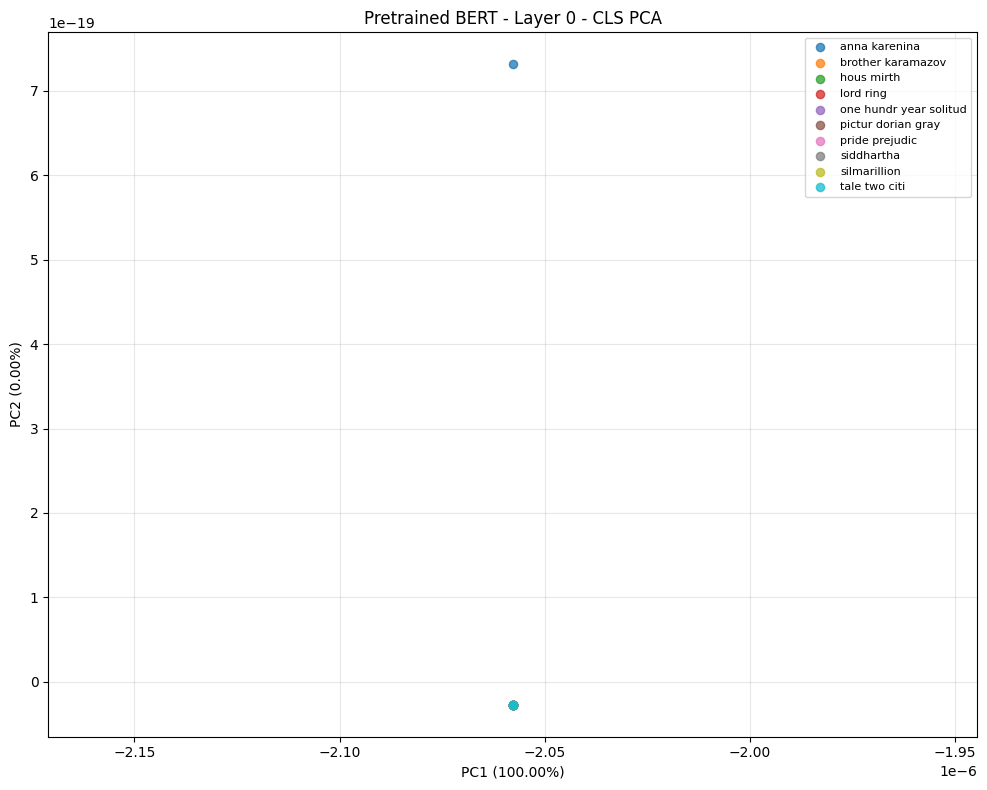

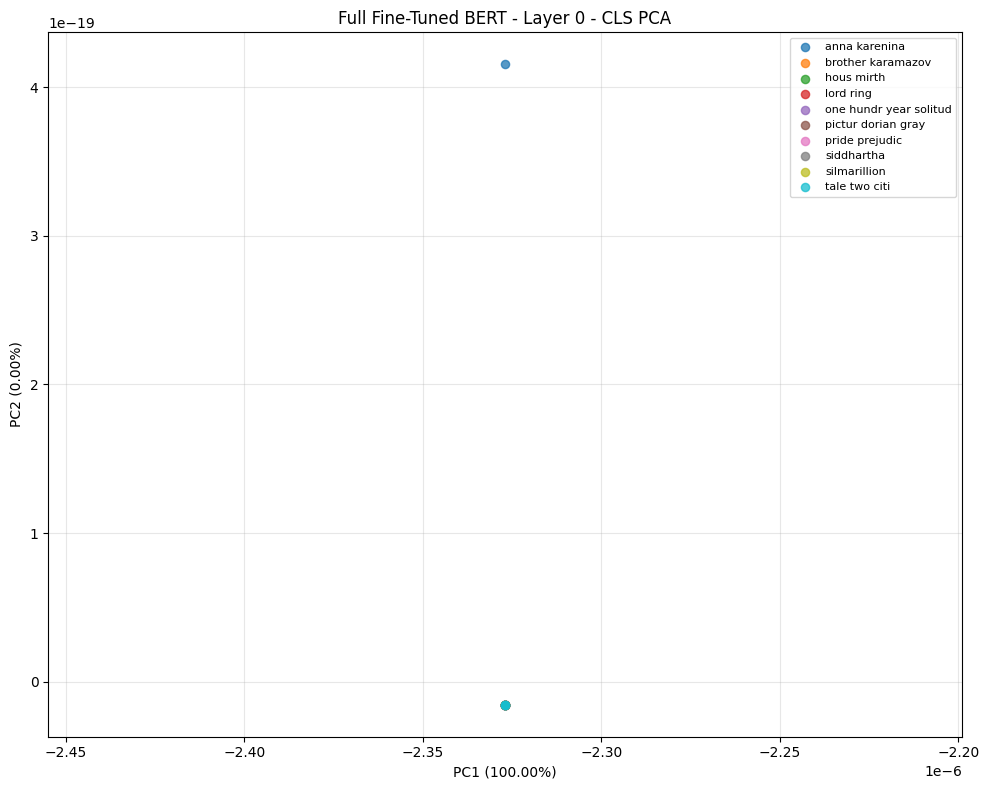

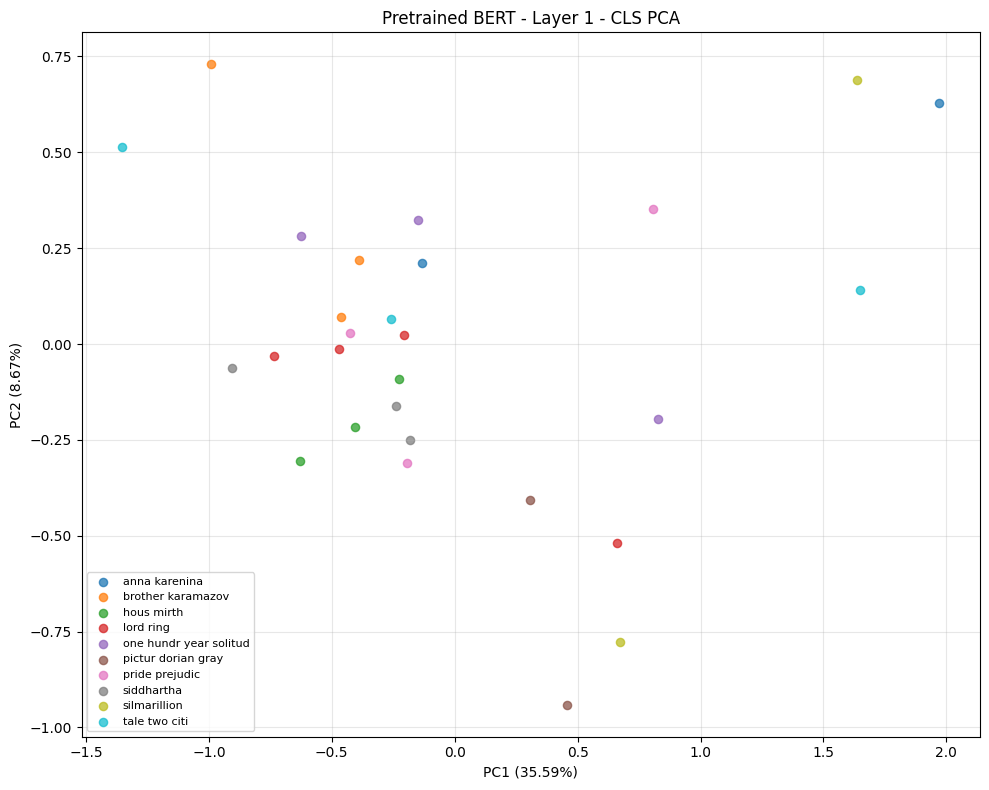

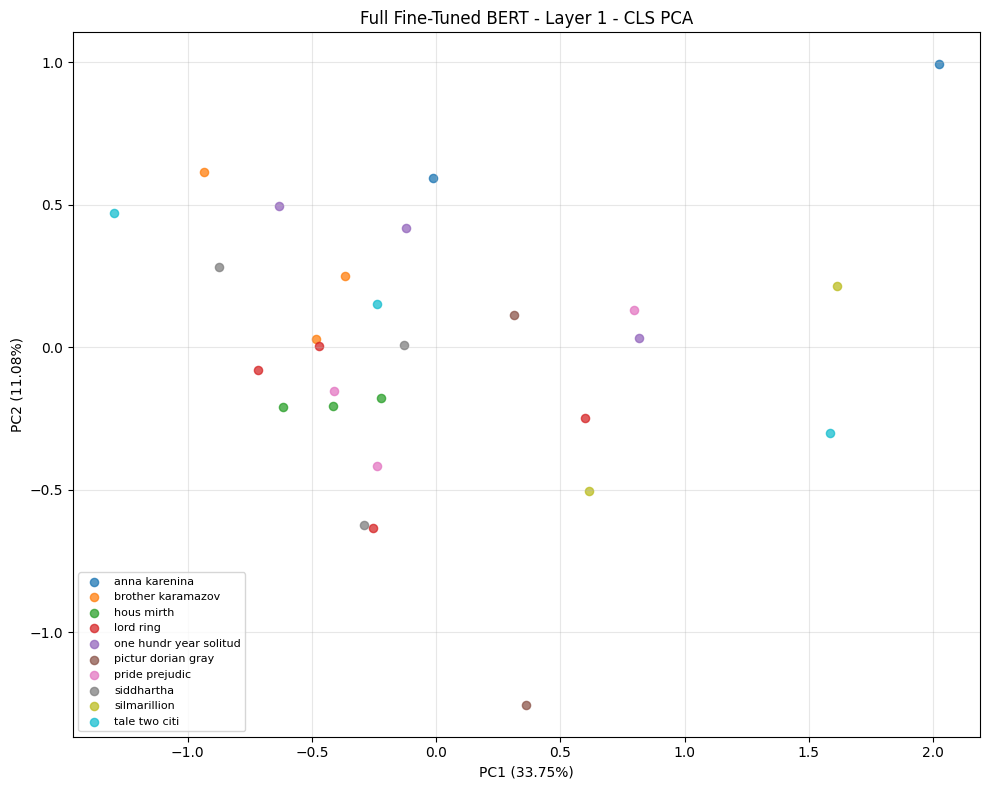

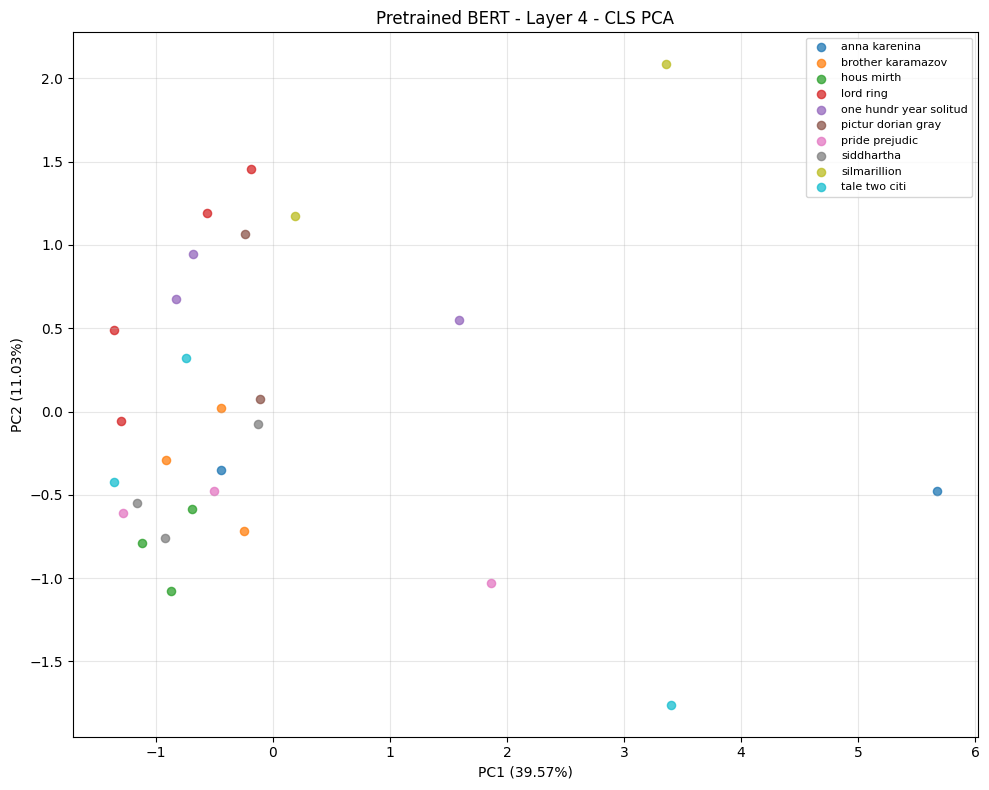

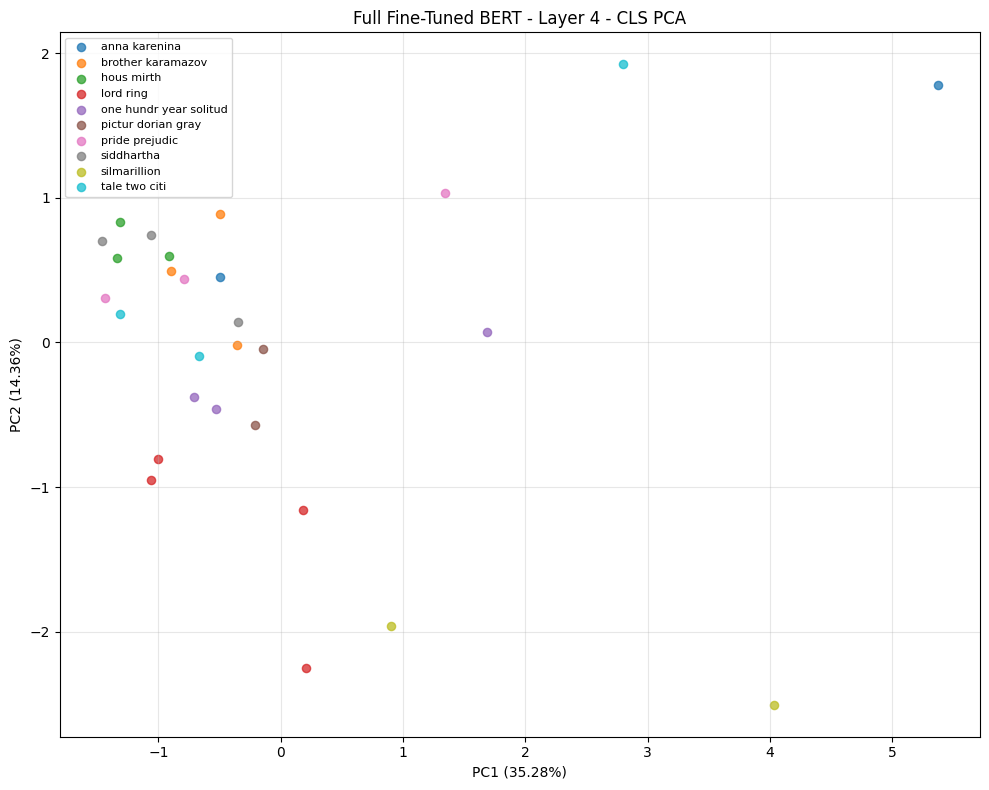

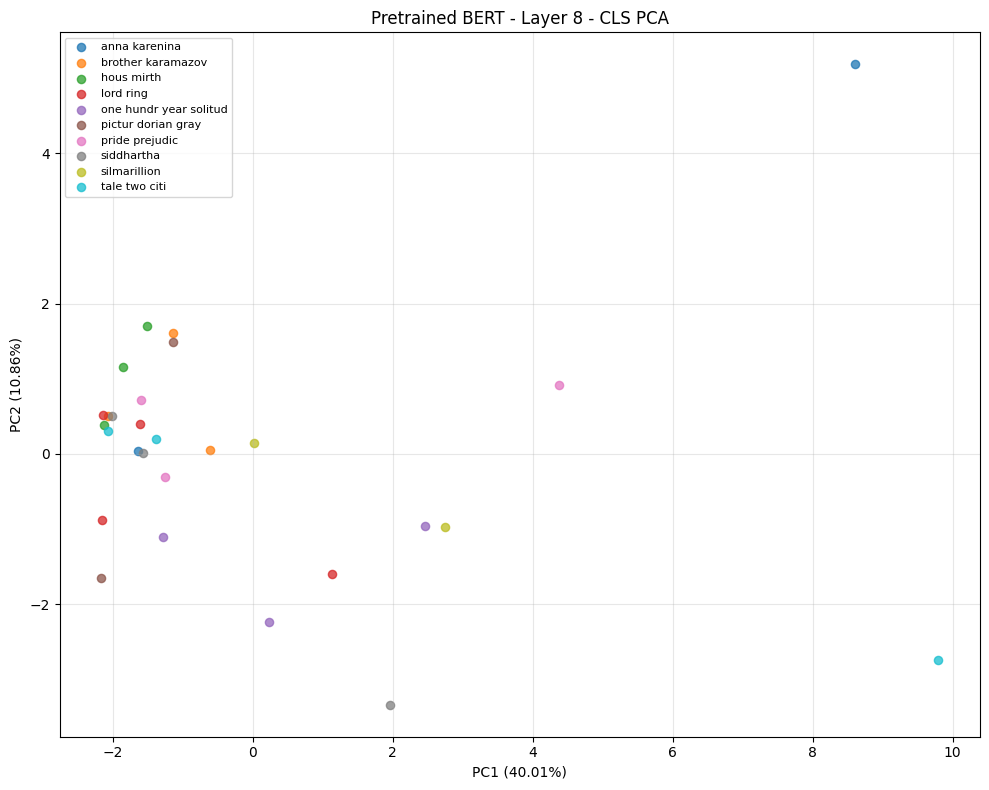

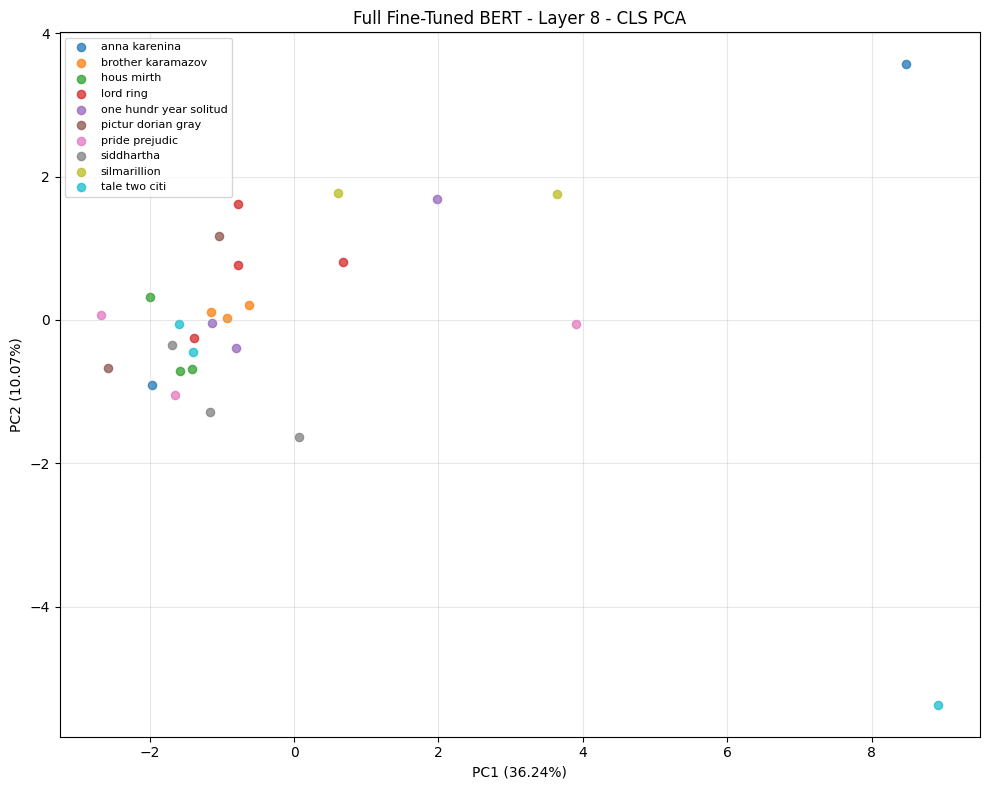

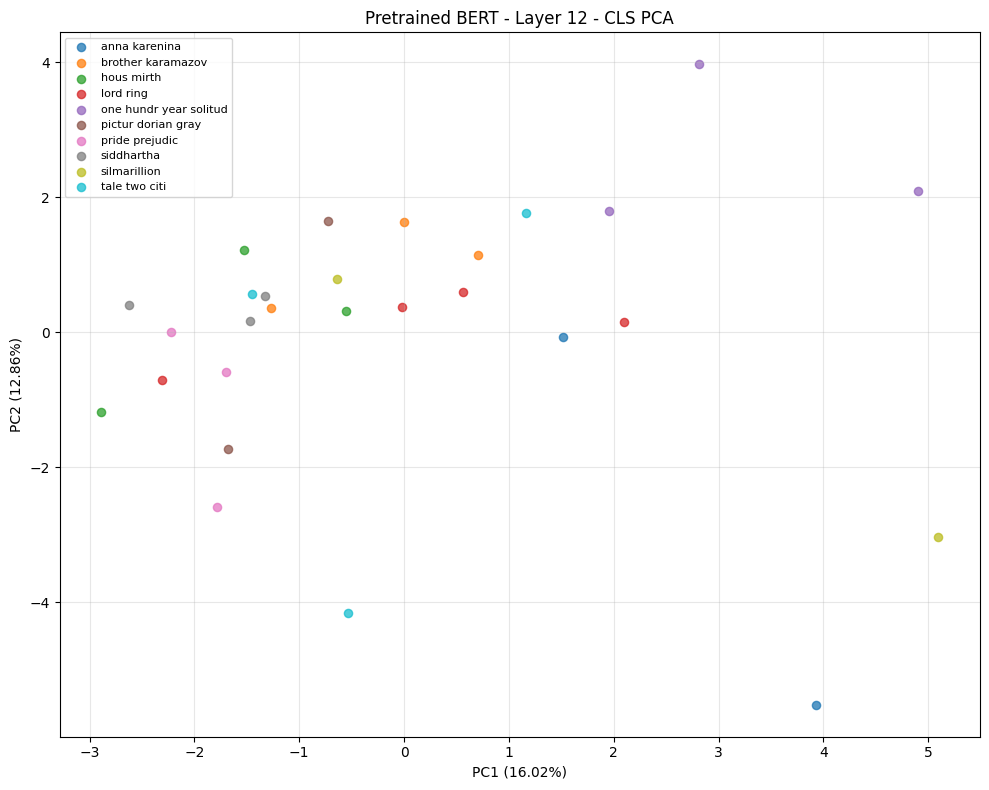

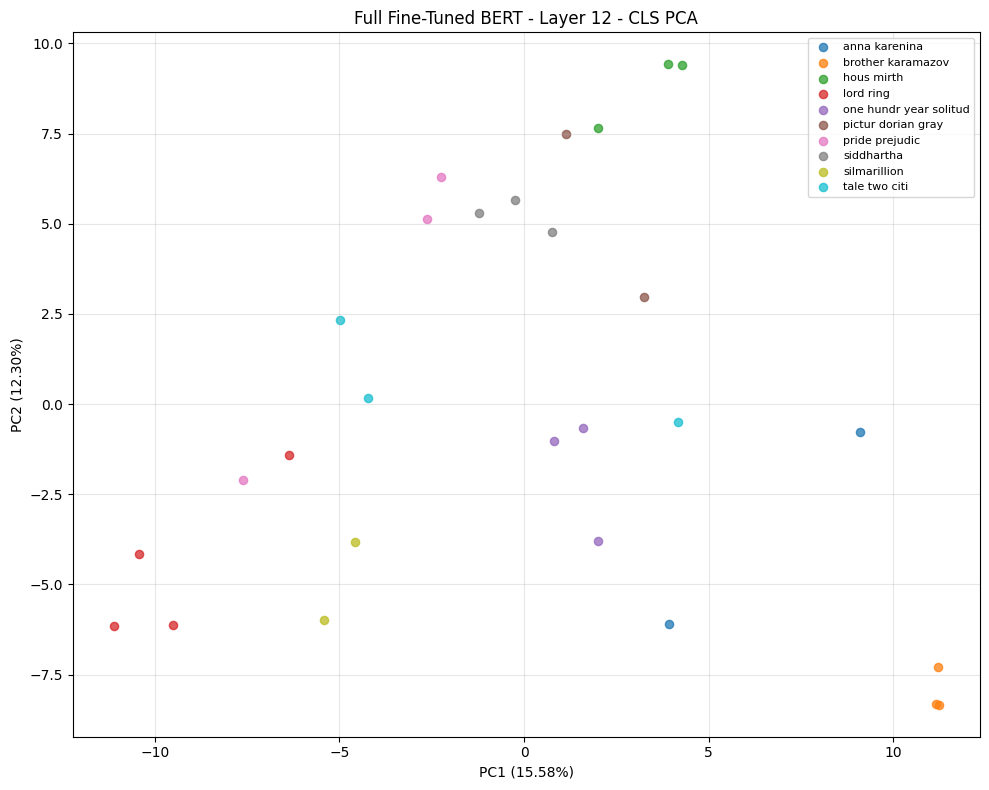

In [ ]:
# =========================================
# Visualize selected layers separately
# =========================================

for layer_idx in SELECTED_LAYERS:

    pretrained_output_file = os.path.join(
        OUTPUT_DIR,
        f"pretrained_layer_{layer_idx}_{POOLING}_pca.png"
    )

    finetuned_output_file = os.path.join(
        OUTPUT_DIR,
        f"finetuned_layer_{layer_idx}_{POOLING}_pca.png"
    )

    visualize_single_layer_pca(
        vectors=pretrained_layer_vectors[layer_idx],
        labels=y_labels,
        label_encoder=label_encoder,
        title=f"Pretrained BERT - Layer {layer_idx} - {POOLING.upper()} PCA",
        output_file=pretrained_output_file
    )

    visualize_single_layer_pca(
        vectors=finetuned_layer_vectors[layer_idx],
        labels=y_labels,
        label_encoder=label_encoder,
        title=f"Full Fine-Tuned BERT - Layer {layer_idx} - {POOLING.upper()} PCA",
        output_file=finetuned_output_file
    )

<h2>Side-by-Side Comparison for One Layer</h2>

In [ ]:
# =========================================
# Side-by-side PCA comparison for one layer
# =========================================
def visualize_layer_comparison_pca(
    pretrained_vectors,
    finetuned_vectors,
    labels,
    label_encoder,
    layer_idx,
    output_file,
):
    """
    Compare pretrained and fine-tuned representations in one common 2D PCA space.
    """
    combined_vectors = np.vstack([pretrained_vectors, finetuned_vectors])
    pca = PCA(n_components=2, random_state=SEED)
    combined_reduced = pca.fit_transform(combined_vectors)

    num_samples = pretrained_vectors.shape[0]
    pretrained_reduced = combined_reduced[:num_samples]
    finetuned_reduced = combined_reduced[num_samples:]
    unique_labels = sorted(np.unique(labels))

    plt.figure(figsize=(18, 7))

    plt.subplot(1, 2, 1)
    for label_id in unique_labels:
        indices = labels == label_id
        plt.scatter(
            pretrained_reduced[indices, 0],
            pretrained_reduced[indices, 1],
            s=30,
            alpha=0.75,
            label=get_class_name(label_id, label_encoder),
        )
    plt.title(f"Pretrained BERT - Layer {layer_idx}")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    for label_id in unique_labels:
        indices = labels == label_id
        plt.scatter(
            finetuned_reduced[indices, 0],
            finetuned_reduced[indices, 1],
            s=30,
            alpha=0.75,
            label=get_class_name(label_id, label_encoder),
        )
    plt.title(f"Full Fine-Tuned BERT - Layer {layer_idx}")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.savefig(output_file, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved:", output_file)


<h2>Run Side-by-Side Comparison for Selected Layers</h2>

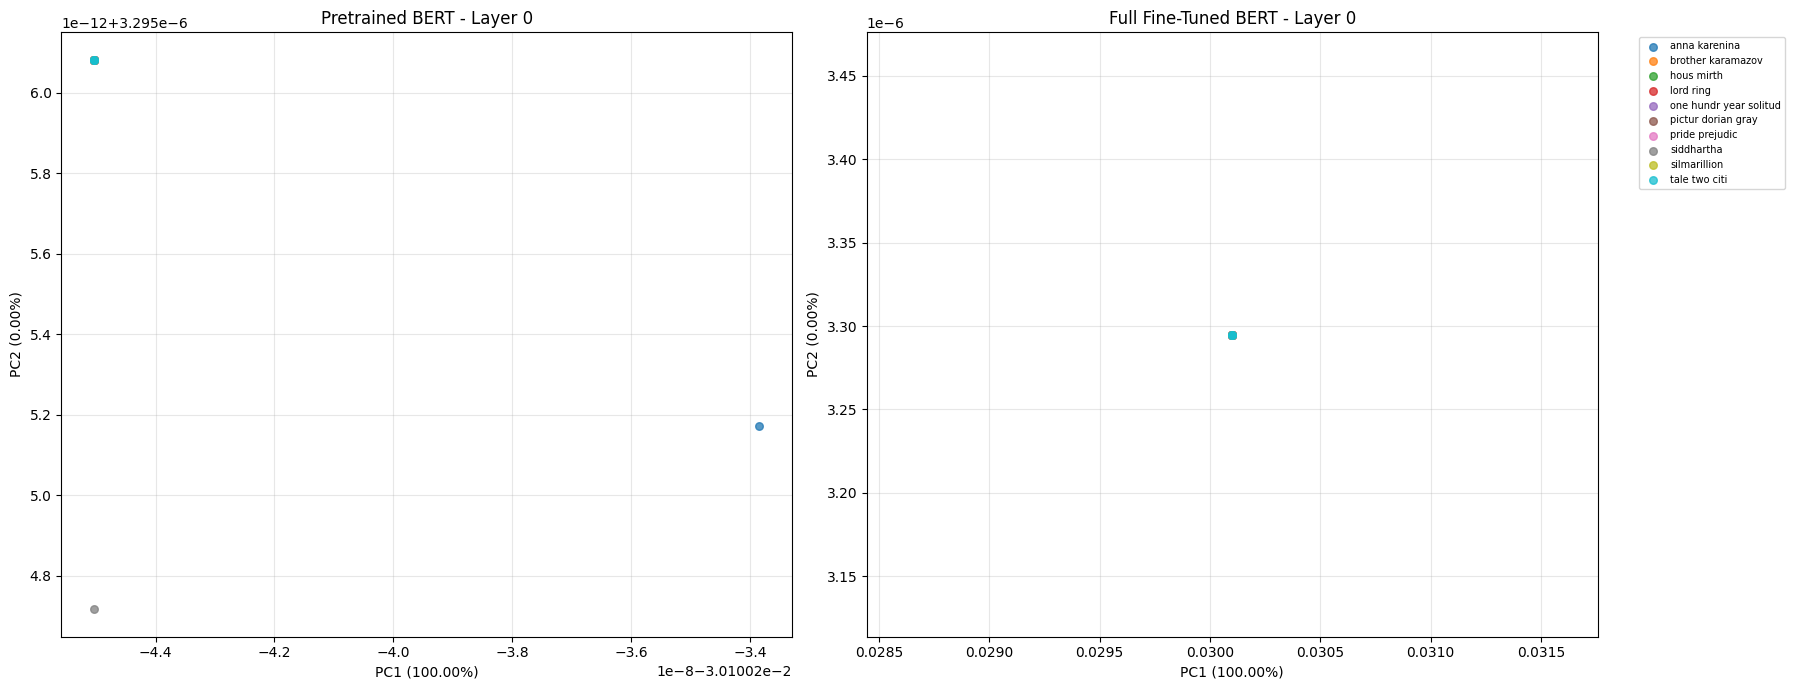

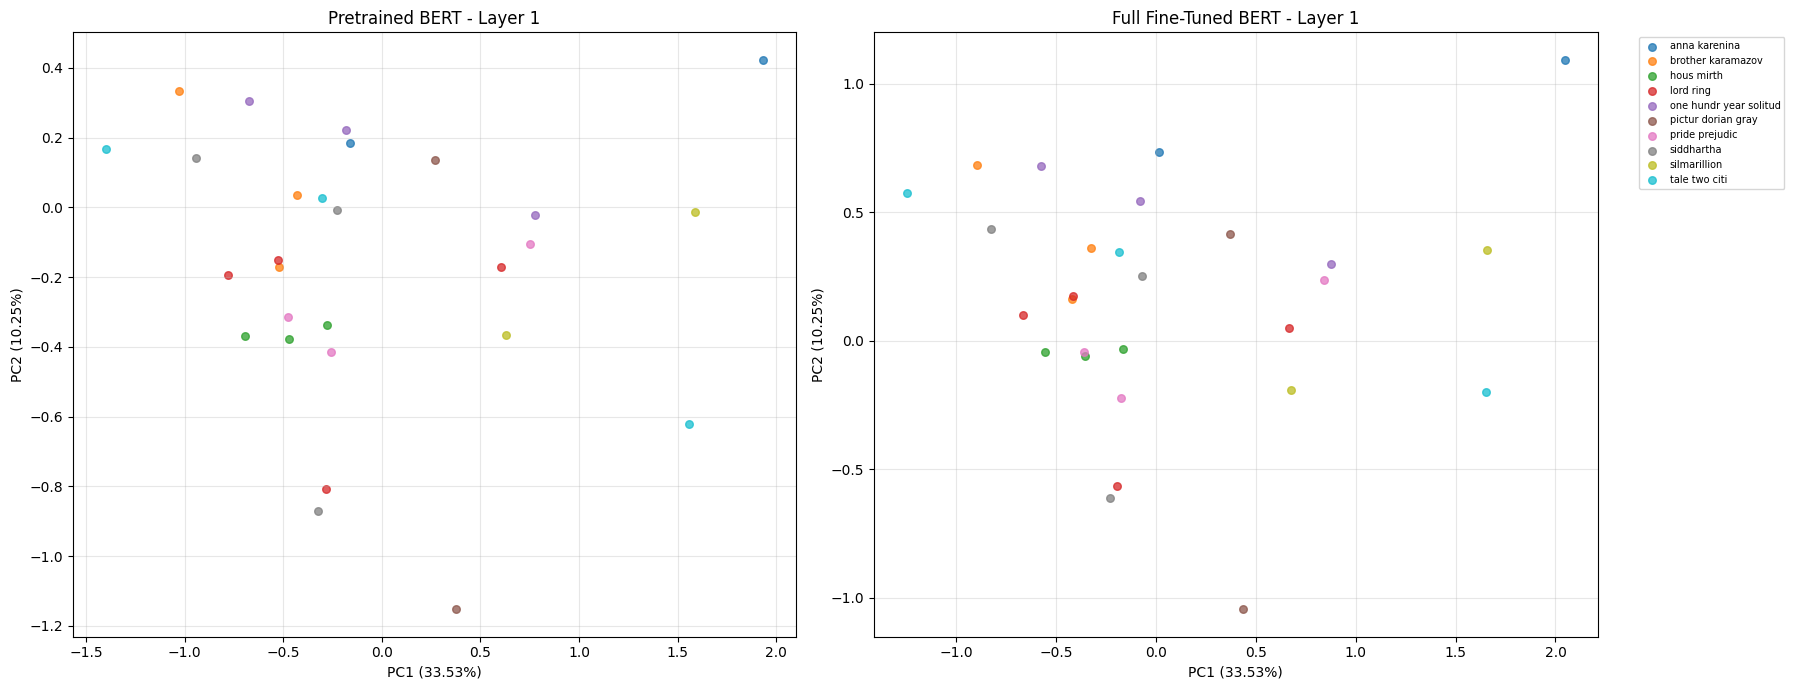

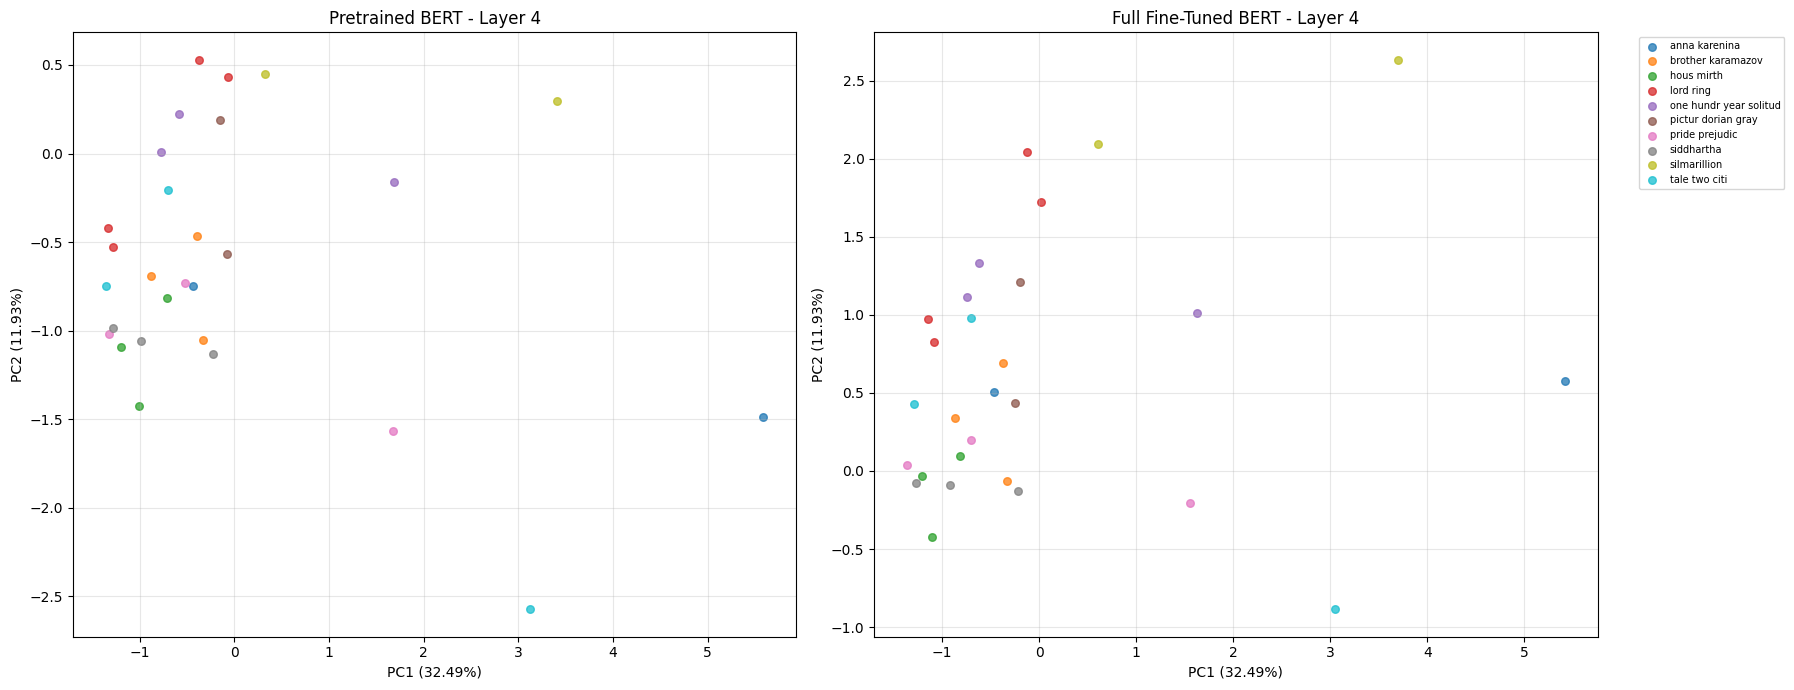

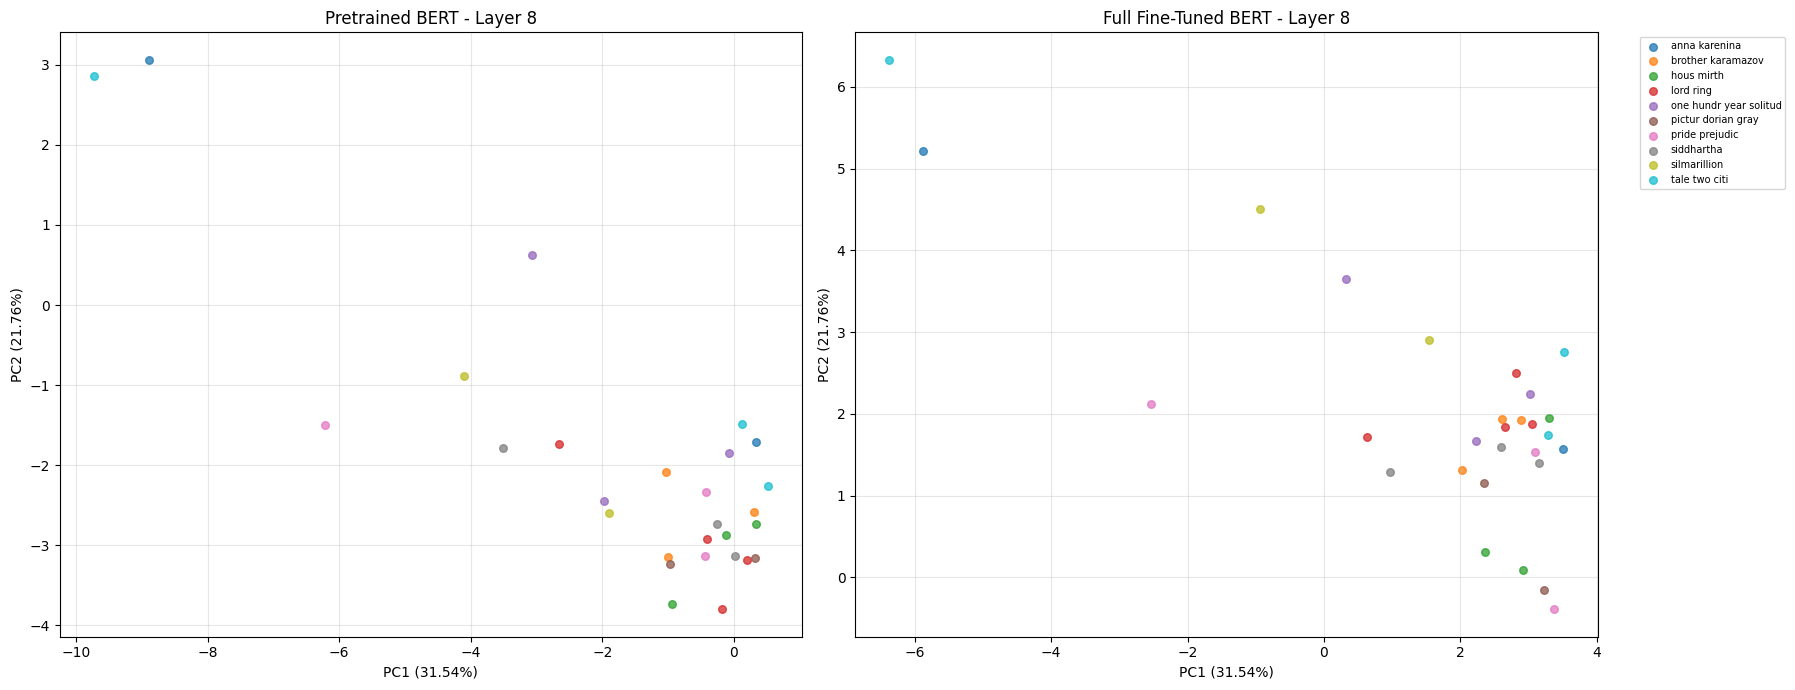

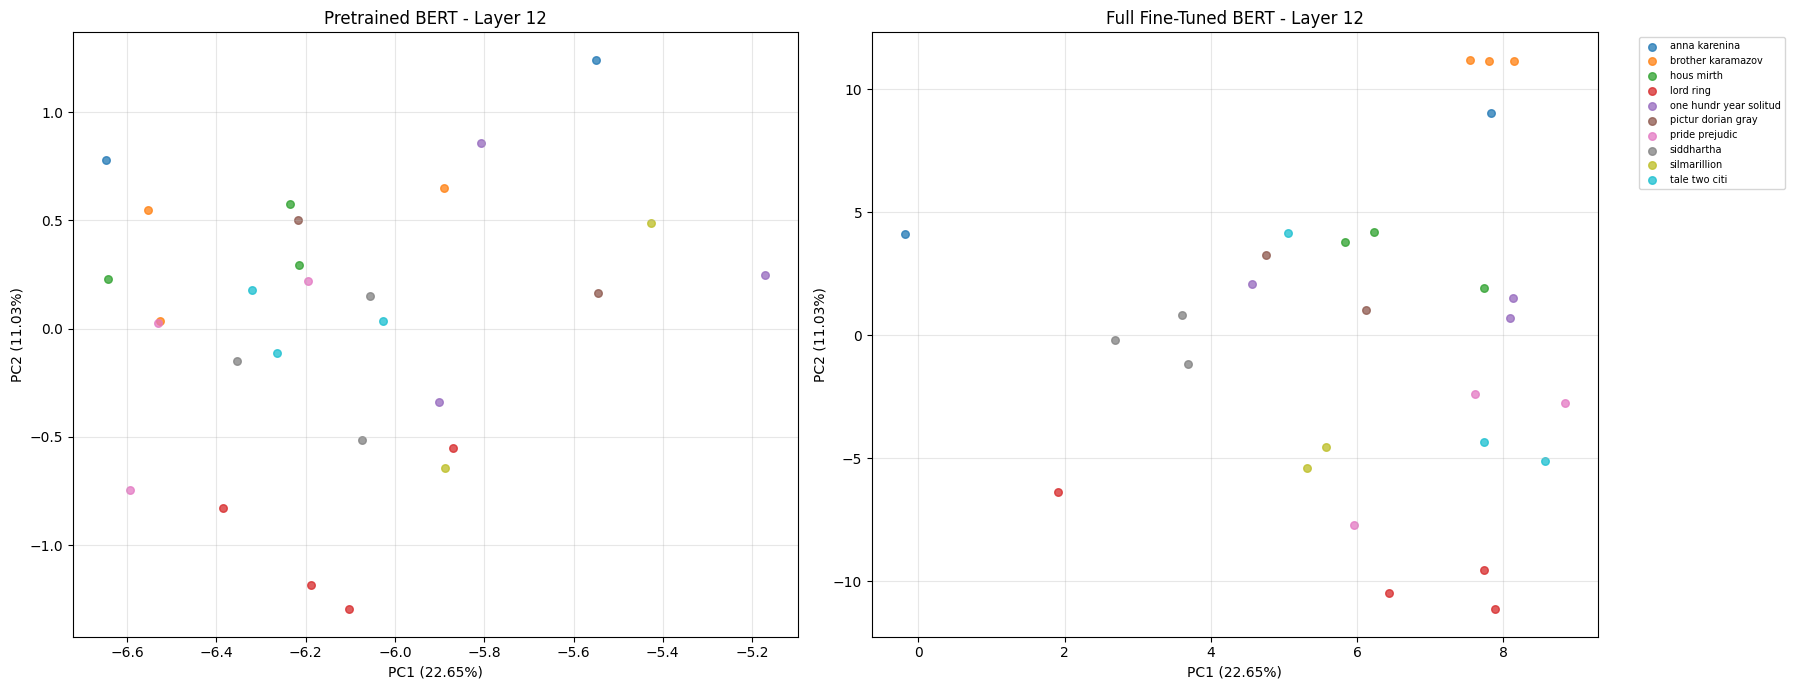

In [ ]:
# =========================================
# Run side-by-side PCA comparison for selected layers
# =========================================

for layer_idx in SELECTED_LAYERS:

    output_file = os.path.join(
        OUTPUT_DIR,
        f"comparison_layer_{layer_idx}_{POOLING}_pca.png"
    )

    visualize_layer_comparison_pca(
        pretrained_vectors=pretrained_layer_vectors[layer_idx],
        finetuned_vectors=finetuned_layer_vectors[layer_idx],
        labels=y_labels,
        label_encoder=label_encoder,
        layer_idx=layer_idx,
        output_file=output_file
    )

<h2>Grid Visualization Across All Layers</h2>

In [ ]:
# =========================================
# Grid visualization across all BERT layers
# =========================================
def visualize_all_layers_grid(
    layer_vectors,
    labels,
    model_name,
    output_file,
):
    """Save a PCA grid for all BERT hidden-state levels."""
    num_layers = len(layer_vectors)
    num_cols = 4
    num_rows = int(np.ceil(num_layers / num_cols))
    unique_labels = sorted(np.unique(labels))

    plt.figure(figsize=(num_cols * 5, num_rows * 4))

    for layer_idx in range(num_layers):
        vectors = layer_vectors[layer_idx]
        pca = PCA(n_components=2, random_state=SEED)
        reduced_vectors = pca.fit_transform(vectors)

        plt.subplot(num_rows, num_cols, layer_idx + 1)
        for label_id in unique_labels:
            indices = labels == label_id
            plt.scatter(
                reduced_vectors[indices, 0],
                reduced_vectors[indices, 1],
                s=12,
                alpha=0.65,
            )

        plt.title(f"Layer {layer_idx}")
        plt.xticks([])
        plt.yticks([])
        plt.grid(True, alpha=0.2)

    plt.suptitle(
        f"{model_name} - Layer-wise PCA - {POOLING.upper()}",
        fontsize=16,
    )
    plt.tight_layout()
    plt.savefig(output_file, dpi=200, bbox_inches="tight")
    plt.close()
    print("Saved:", output_file)


<h2>Save Grid Plots for Both Models</h2>

In [ ]:
# =========================================
# Plot all BERT layers in a grid
# =========================================
def plot_all_layers_grid(
    layer_vectors,
    labels,
    model_name,
    output_file=None,
    show_plot=True,
):
    """Display and optionally save layer-wise PCA plots."""
    num_layers = len(layer_vectors)
    num_cols = 4
    num_rows = int(np.ceil(num_layers / num_cols))
    unique_labels = sorted(np.unique(labels))

    plt.figure(figsize=(num_cols * 5, num_rows * 4))

    for layer_idx in range(num_layers):
        vectors = layer_vectors[layer_idx]
        pca = PCA(n_components=2, random_state=SEED)
        reduced_vectors = pca.fit_transform(vectors)

        plt.subplot(num_rows, num_cols, layer_idx + 1)
        for label_id in unique_labels:
            indices = labels == label_id
            plt.scatter(
                reduced_vectors[indices, 0],
                reduced_vectors[indices, 1],
                s=12,
                alpha=0.65,
            )

        plt.title(
            f"Layer {layer_idx}\n"
            f"PC1={pca.explained_variance_ratio_[0]:.1%}, "
            f"PC2={pca.explained_variance_ratio_[1]:.1%}"
        )
        plt.xticks([])
        plt.yticks([])
        plt.grid(True, alpha=0.2)

    plt.suptitle(
        f"{model_name} - Layer-wise PCA - {POOLING.upper()}",
        fontsize=16,
    )
    plt.tight_layout()

    if output_file is not None:
        plt.savefig(output_file, dpi=200, bbox_inches="tight")
        print("Saved:", output_file)

    if show_plot:
        plt.show()
    else:
        plt.close()


<h2>Plot Pretrained BERT Grid</h2>

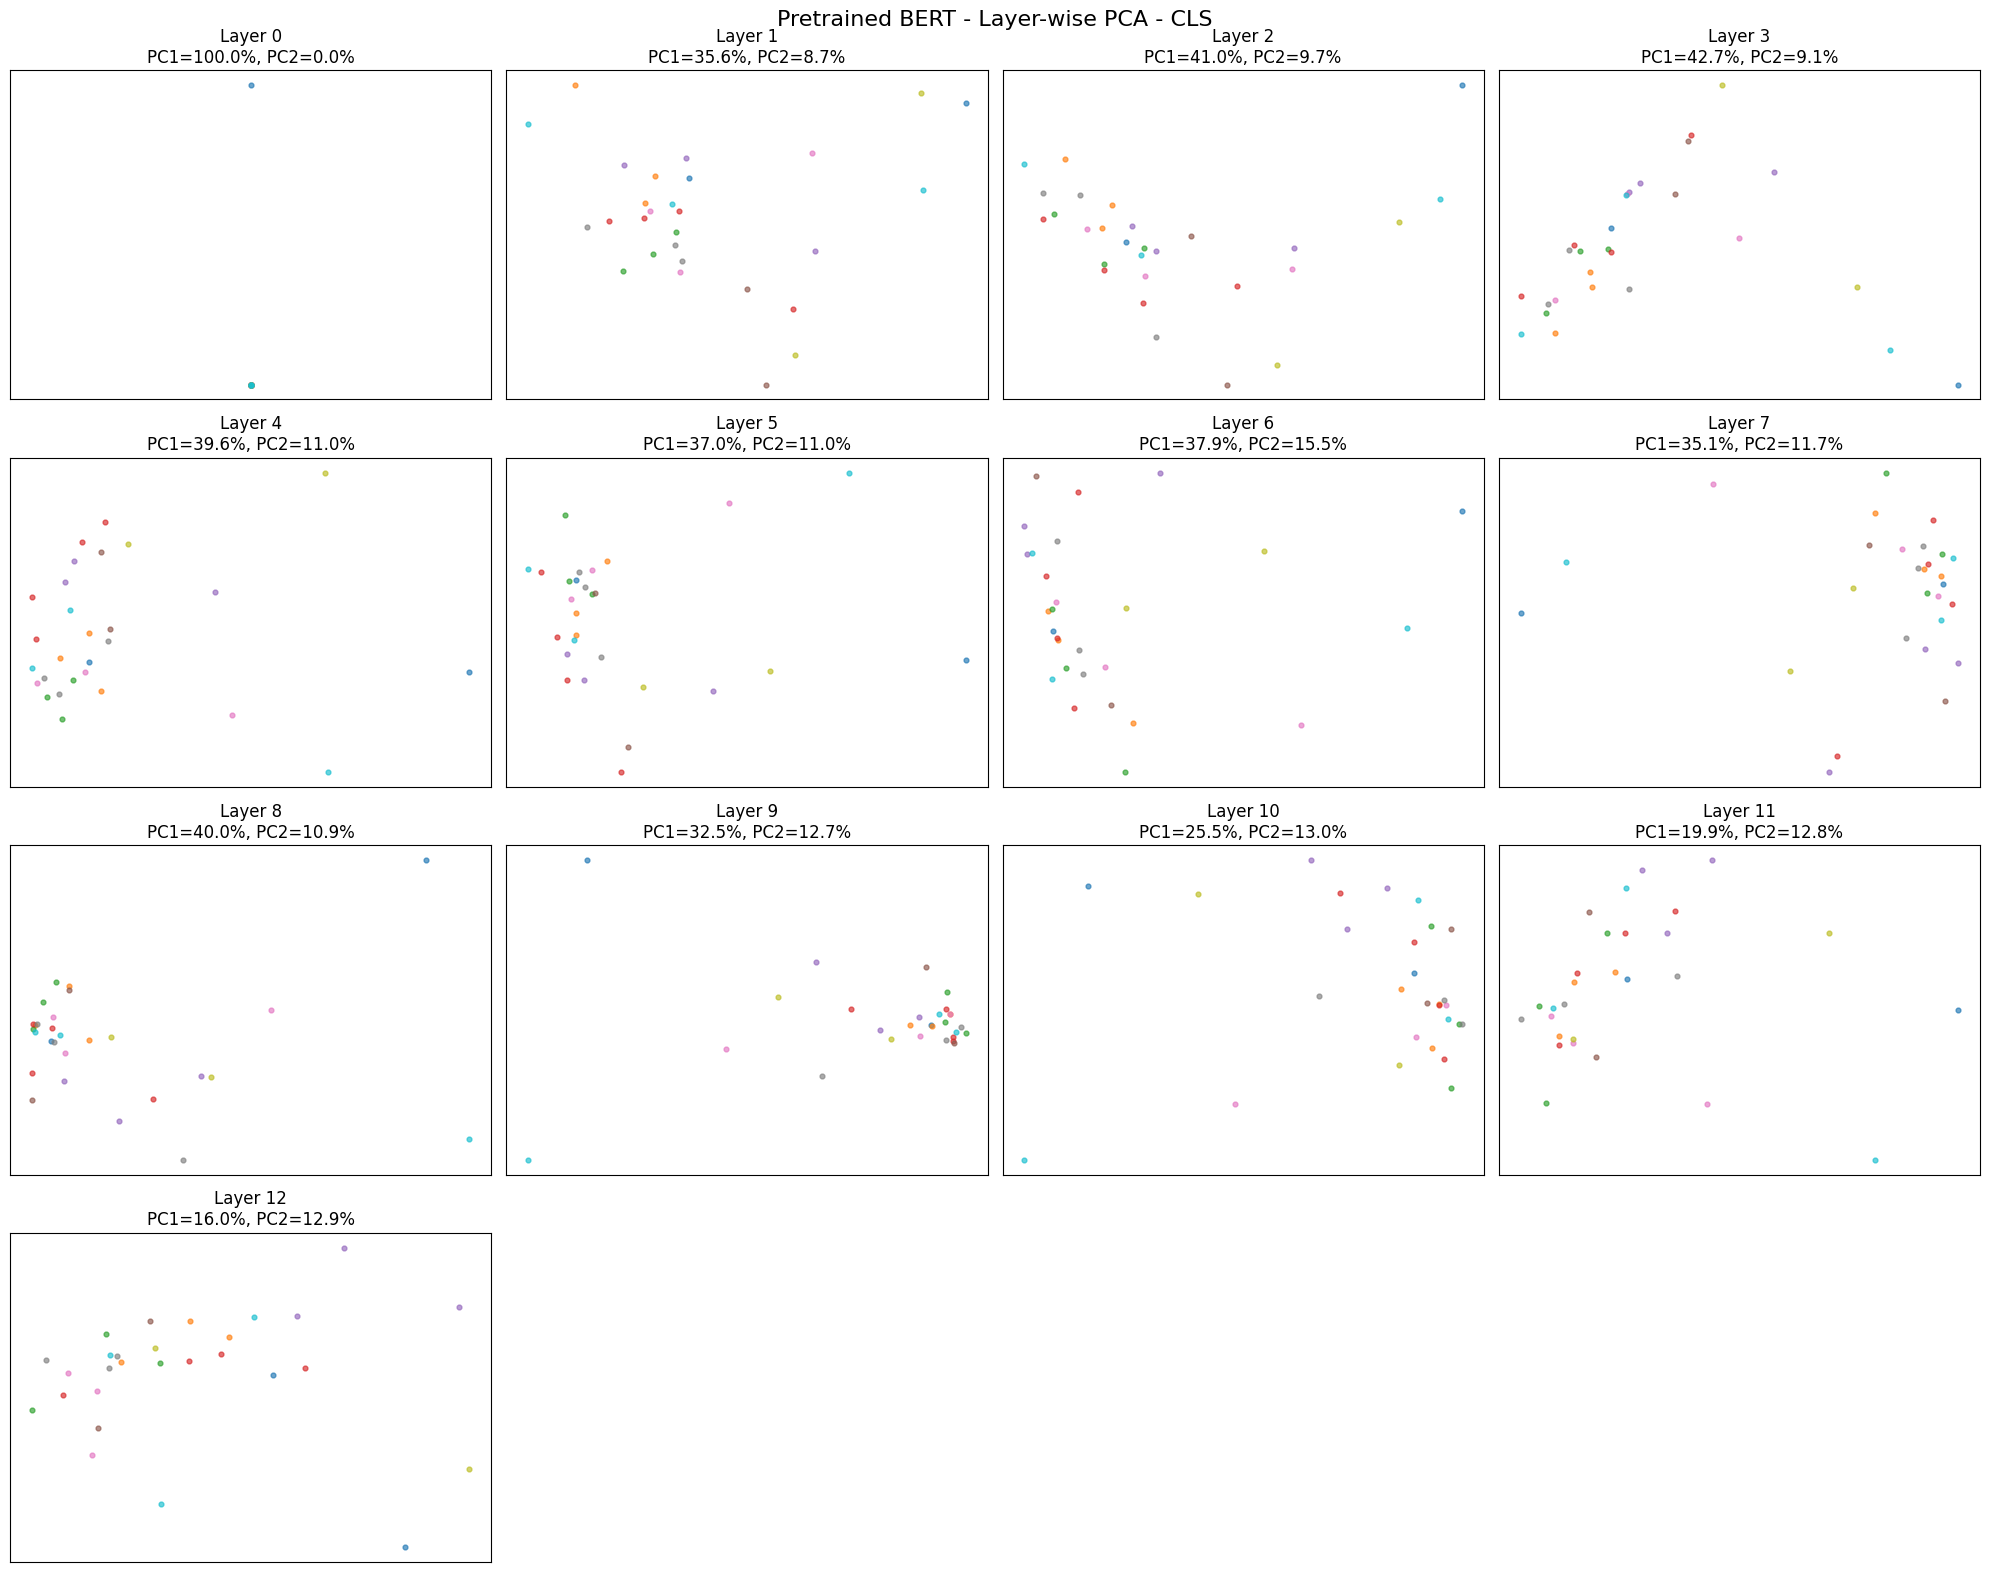

In [ ]:
# =========================================
# Plot pretrained BERT layer-wise PCA grid
# =========================================

pretrained_grid_file = os.path.join(
    OUTPUT_DIR,
    f"pretrained_all_layers_{POOLING}_grid.png"
)

plot_all_layers_grid(
    layer_vectors=pretrained_layer_vectors,
    labels=y_labels,
    model_name="Pretrained BERT",
    output_file=pretrained_grid_file,
    show_plot=True
)

<h2>Plot Full Fine-Tuned BERT Grid</h2>

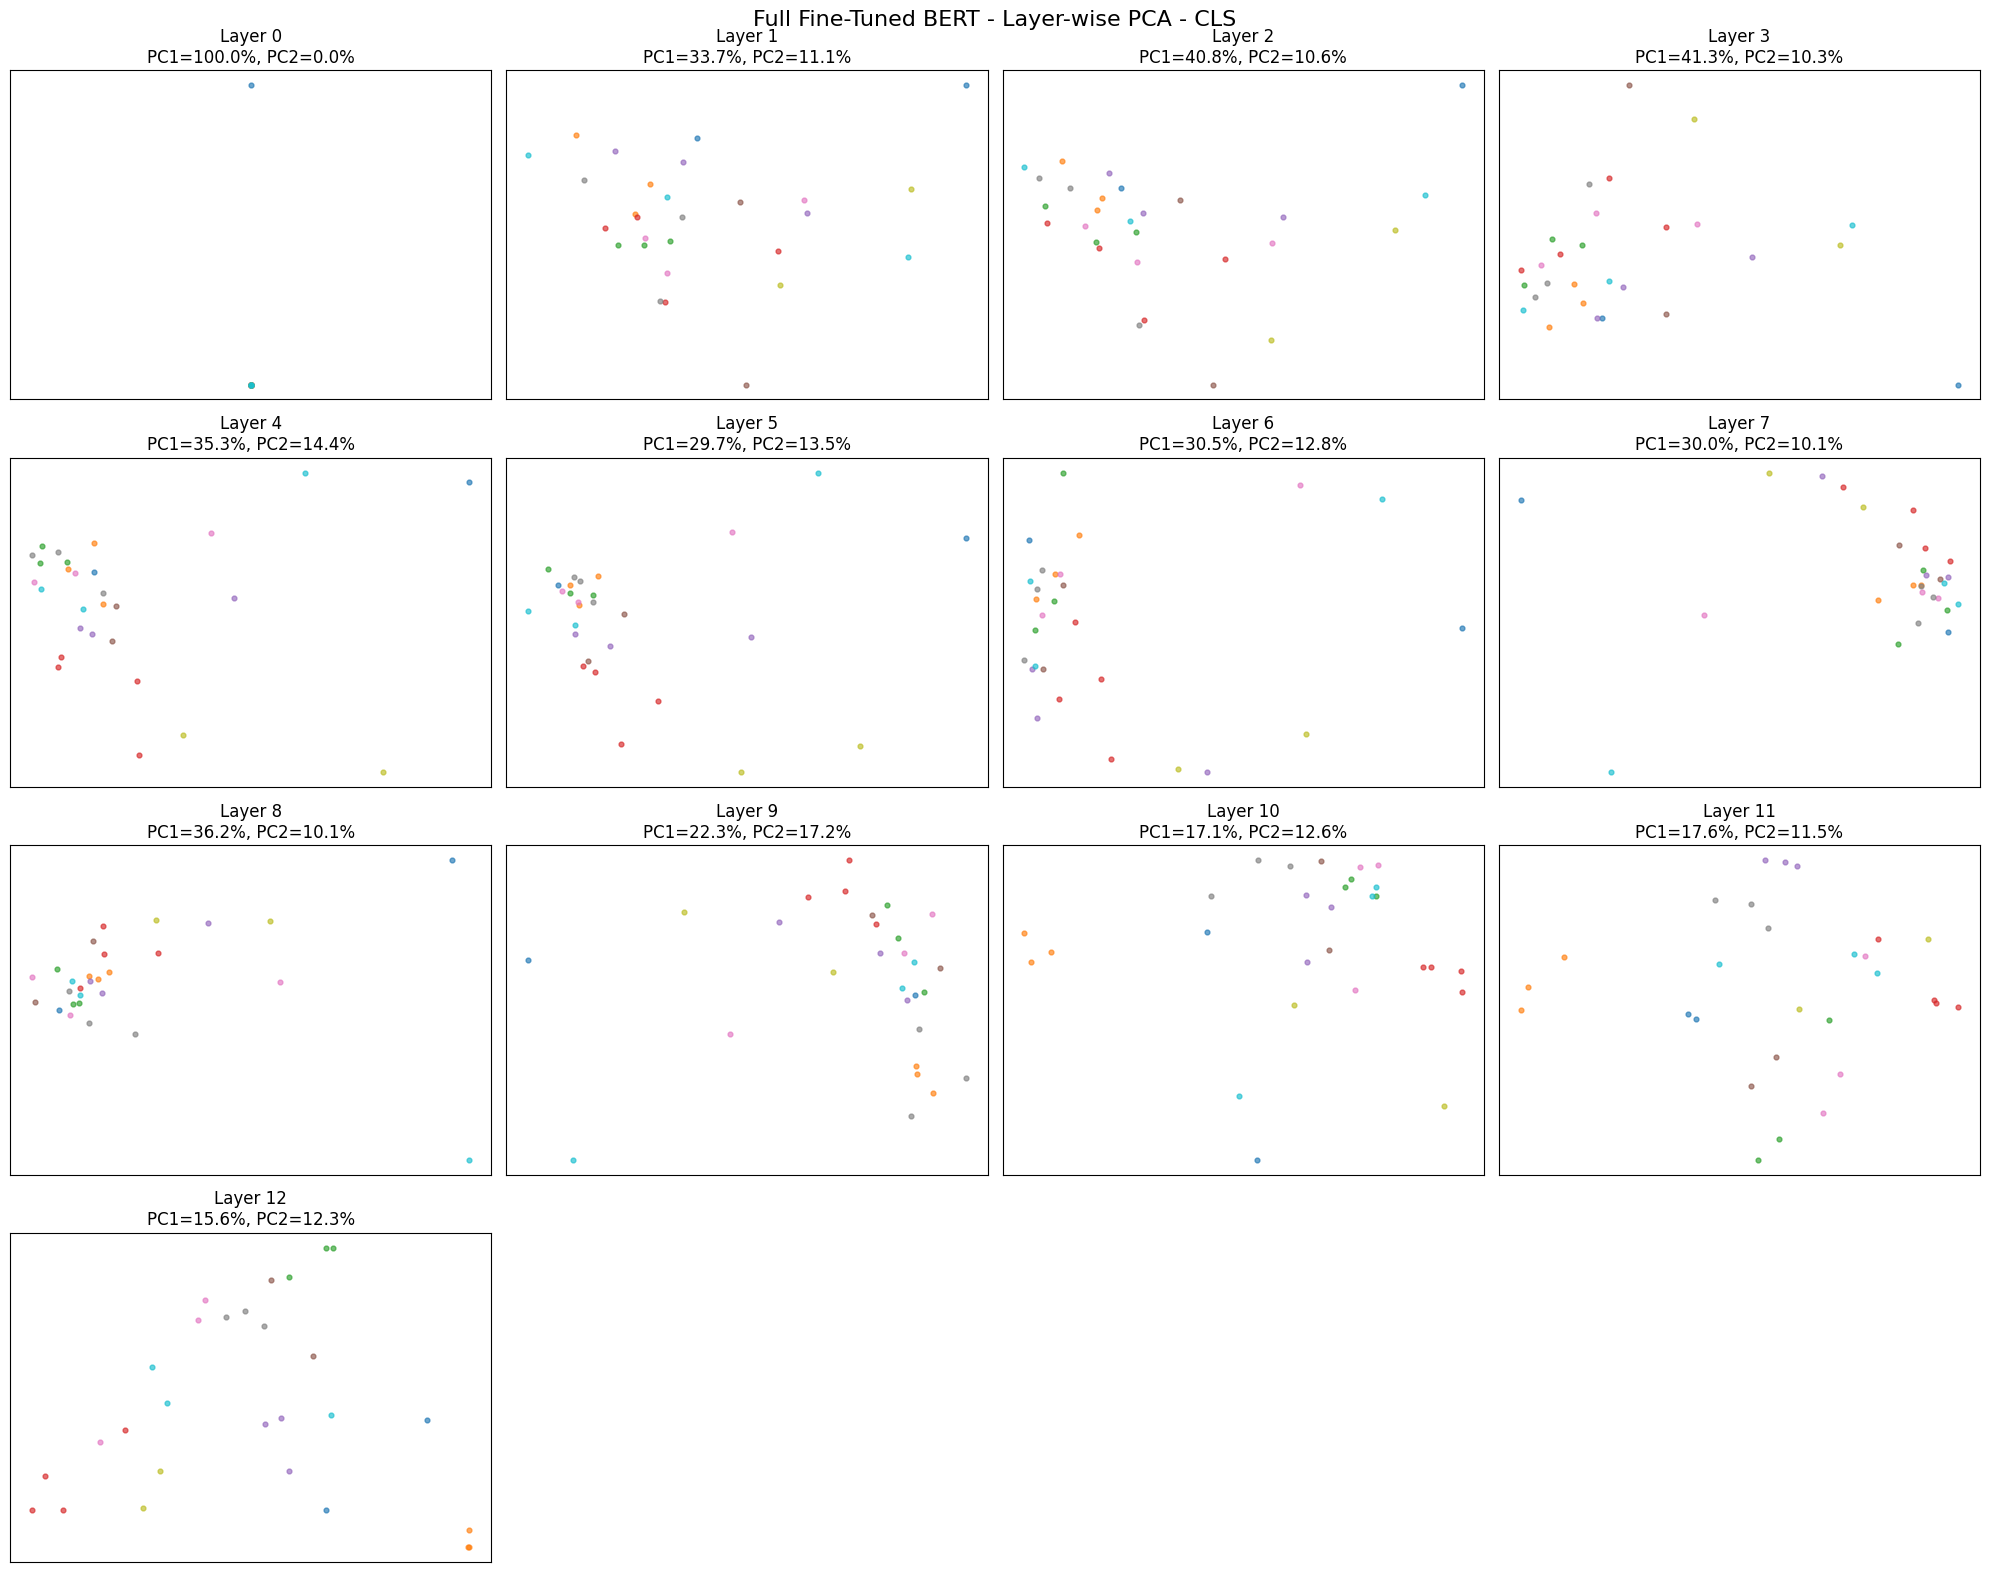

In [ ]:
# =========================================
# Plot full fine-tuned BERT layer-wise PCA grid
# =========================================

finetuned_grid_file = os.path.join(
    OUTPUT_DIR,
    f"finetuned_all_layers_{POOLING}_grid.png"
)

plot_all_layers_grid(
    layer_vectors=finetuned_layer_vectors,
    labels=y_labels,
    model_name="Full Fine-Tuned BERT",
    output_file=finetuned_grid_file,
    show_plot=True
)

<h2>Compute Layer-Wise Silhouette Score</h2>

In [ ]:
# =========================================
# Compute layer-wise class separability
# =========================================
def compute_layer_silhouette_scores(layer_vectors, labels):
    """Compute class-label silhouette scores for each BERT layer."""
    scores = {}

    for layer_idx, vectors in layer_vectors.items():
        try:
            score = silhouette_score(vectors, labels, metric="euclidean")
        except Exception as error:
            print(f"Layer {layer_idx} failed: {error}")
            score = np.nan
        scores[layer_idx] = score

    return scores


pretrained_silhouette_scores = compute_layer_silhouette_scores(
    pretrained_layer_vectors,
    y_labels,
)
finetuned_silhouette_scores = compute_layer_silhouette_scores(
    finetuned_layer_vectors,
    y_labels,
)

print("Pretrained BERT silhouette scores:")
print(pretrained_silhouette_scores)
print("Full fine-tuned BERT silhouette scores:")
print(finetuned_silhouette_scores)


<h2>Plot Layer-Wise Silhouette Scores</h2>

In [ ]:
# =========================================
# Plot layer-wise silhouette scores
# =========================================
def plot_layerwise_silhouette_scores(
    pretrained_scores,
    finetuned_scores,
    output_file=None,
    show_plot=True,
):
    """Plot class separability changes across BERT layers."""
    layers = sorted(pretrained_scores)
    if layers != sorted(finetuned_scores):
        raise ValueError("The two score dictionaries must contain the same layers.")

    pretrained_values = [pretrained_scores[layer] for layer in layers]
    finetuned_values = [finetuned_scores[layer] for layer in layers]

    plt.figure(figsize=(10, 6))
    plt.plot(
        layers,
        pretrained_values,
        marker="o",
        linewidth=2,
        label="Pretrained BERT",
    )
    plt.plot(
        layers,
        finetuned_values,
        marker="o",
        linewidth=2,
        label="Full Fine-Tuned BERT",
    )
    plt.xlabel("Layer")
    plt.ylabel("Silhouette Score")
    plt.title("Layer-wise Class Separability")
    plt.xticks(layers)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if output_file is not None:
        plt.savefig(output_file, dpi=200, bbox_inches="tight")
        print("Saved:", output_file)

    if show_plot:
        plt.show()
    else:
        plt.close()


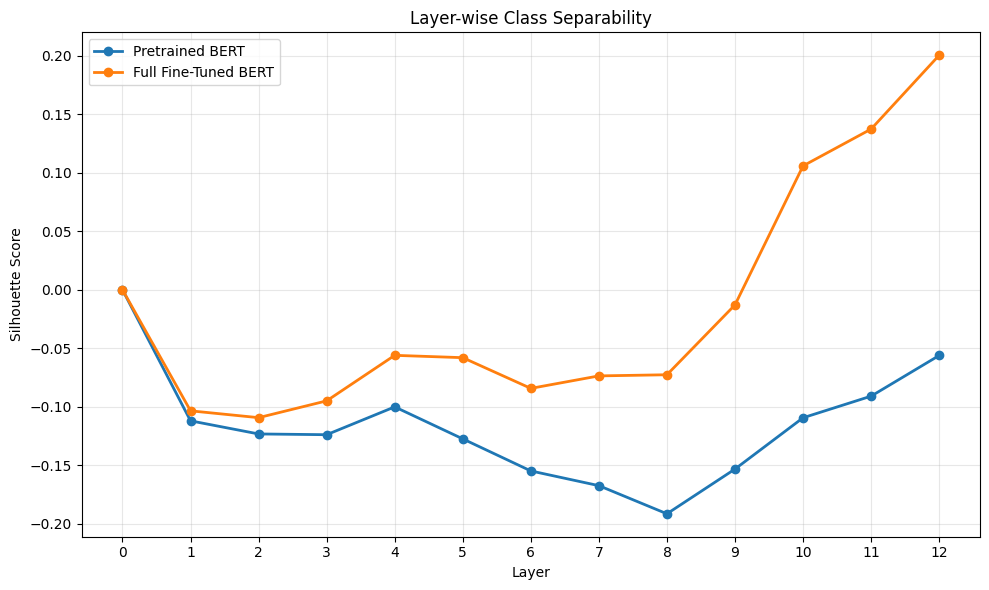

In [ ]:
# =========================================
# Save and display the layer-wise silhouette plot
# =========================================

silhouette_plot_file = os.path.join(
    OUTPUT_DIR,
    f"layerwise_silhouette_{POOLING}.png"
)

plot_layerwise_silhouette_scores(
    pretrained_scores=pretrained_silhouette_scores,
    finetuned_scores=finetuned_silhouette_scores,
    output_file=silhouette_plot_file,
    show_plot=True
)